<Axes: >

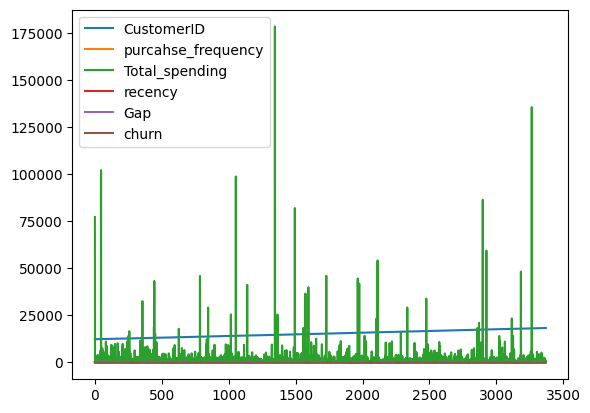

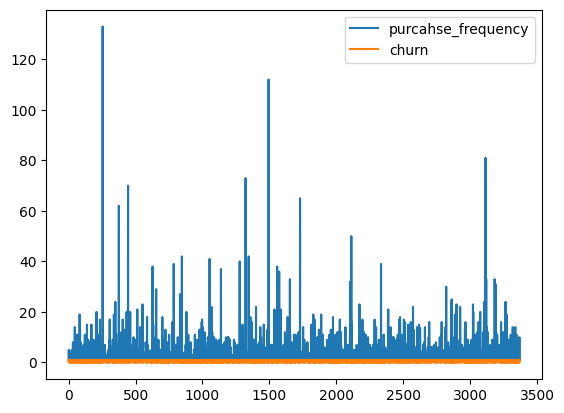

In [5]:
import pandas as pd
training_df=pd.read_csv("Training_data.csv")

training_df.plot()

training_df[['purcahse_frequency','churn']].plot()

In [2]:
X=training_df[[
    "purcahse_frequency",
    "Total_spending",
    "recency"
]]
y=training_df["churn"]

In [3]:
X.head()
y.head()

0    1
1    0
2    1
3    1
4    1
Name: churn, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2696, 3)
(674, 3)
(2696,)
(674,)


In [6]:
# trainig ML model
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
y_pred=model.predict(X_test)
print(y_pred[:20])
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy : ",accuracy)
print(classification_report(y_test,y_pred))


[0 0 1 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1]
Accuracy :  0.8531157270029673
              precision    recall  f1-score   support

           0       0.75      0.74      0.75       198
           1       0.89      0.90      0.90       476

    accuracy                           0.85       674
   macro avg       0.82      0.82      0.82       674
weighted avg       0.85      0.85      0.85       674



In [8]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[147  51]
 [ 48 428]]


In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
dt_pred=dt_model.predict(X_test)
print(accuracy_score(y_test,dt_pred))
print(classification_report(y_test,dt_pred))
print(confusion_matrix(y_test,dt_pred))

0.8204747774480712
              precision    recall  f1-score   support

           0       0.69      0.70      0.70       198
           1       0.87      0.87      0.87       476

    accuracy                           0.82       674
   macro avg       0.78      0.78      0.78       674
weighted avg       0.82      0.82      0.82       674

[[138  60]
 [ 61 415]]


In [11]:
from sklearn.ensemble import RandomForestClassifier


In [13]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)
print(accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))
print(confusion_matrix(y_test,rf_pred))

0.8486646884272997
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       198
           1       0.90      0.88      0.89       476

    accuracy                           0.85       674
   macro avg       0.82      0.83      0.82       674
weighted avg       0.85      0.85      0.85       674

[[152  46]
 [ 56 420]]


In [15]:
from xgboost import XGBClassifier

In [17]:
xgb_model=XGBClassifier(random_state=42)
xgb_model.fit(X_train,y_train)
xgb_pred=xgb_model.predict(X_test)
print(accuracy_score(y_test,xgb_pred))
print(classification_report(y_test,xgb_pred))
print(confusion_matrix(y_test,xgb_pred))

0.8293768545994066
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       198
           1       0.88      0.87      0.88       476

    accuracy                           0.83       674
   macro avg       0.79      0.80      0.80       674
weighted avg       0.83      0.83      0.83       674

[[143  55]
 [ 60 416]]


In [18]:
final_model=LogisticRegression(max_iter=1000)
final_model.fit(X,y)
import joblib
joblib.dump(final_model,"churn_model.pkl")

['churn_model.pkl']